# Customer Segmentation using RFM Analysis and K-Means Clustering
## Business Understanding
### Problem Statement

An online retail company serves thousands of customers worldwide. Treating every customer the same can lead to ineffective marketing campaigns and lower customer satisfaction. The company wants to understand different purchasing behaviors so it can target customers with personalized marketing strategies.

### Business Objective

The objective of this project is to segment customers based on their purchasing behavior using RFM (Recency, Frequency, Monetary) Analysis and K-Means Clustering. The resulting customer segments will help the business improve customer retention, increase sales, and optimize marketing efforts.

### Success Criteria
- Clean and prepare transaction data.
- Create RFM features for each customer.
- Determine the optimal number of customer clusters.
- Build a K-Means clustering model.
- Interpret each customer segment.
- Provide actionable business recommendations.

In [172]:
# loading of the libraries 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbn 
import numpy as np

#importation of the algorithms
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans 
from sklearn.metrics import silhouette_score 
from sklearn.preprocessing import RobustScaler
from sklearn.mixture import GaussianMixture
from sklearn.cluster import DBSCAN

In [173]:
#loading of the dataset 
df = pd.read_csv('online_retail_II.csv',index_col=False)
#displaying of the first rows 
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## Data Understanding

In [174]:
df.info() # dataset information

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


In [175]:
df.shape # data set shape

(1067371, 8)

In [176]:
df.tail() # last five rows of the dataset

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


In [177]:
df.describe() # statics summary 

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [178]:
df.isnull().sum() #checking the columns with the nulls 


Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [179]:
df.duplicated().sum()# the sum of the duplicates 


np.int64(34335)

In [180]:
#checking the unique customers
df['Customer ID'].nunique()

5942

In [181]:
df.dtypes

Invoice            str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
Price          float64
Customer ID    float64
Country            str
dtype: object

## Data cleaning 

In [182]:
df.drop_duplicates(inplace=True) #removing the duplicates
df.dropna(inplace=True)
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate']) #converting the involvedate to datrtime
df['Year']=df['InvoiceDate'].dt.to_period('Y')
df['Day']=df['InvoiceDate'].dt.to_period('D')
df=df[df['Price'] > 0]  #  removing the negative price 
df= df[df['Quantity'] > 0] # removing the negative Quantities 
df=df[~df['Invoice'].astype(str).str.startswith("C")] # removal of cancelled involvees 
df['Customer ID']=df['Customer ID'].astype(int)
df['TotalPrice']=df['Price']* df['Quantity']



In [183]:
df.dtypes

Invoice                   str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID             int64
Country                   str
Year            period[Y-DEC]
Day                 period[D]
TotalPrice            float64
dtype: object

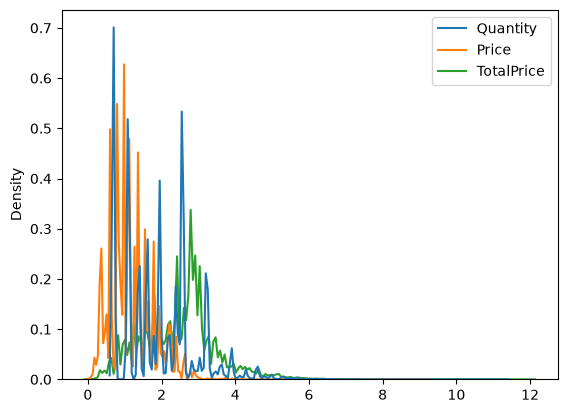

In [184]:
df_log =np.log1p(df[['Quantity','Price','TotalPrice']])
sbn.kdeplot(df_log,bw_adjust=0.5)
plt.show()

## Exploratory Data Analysis

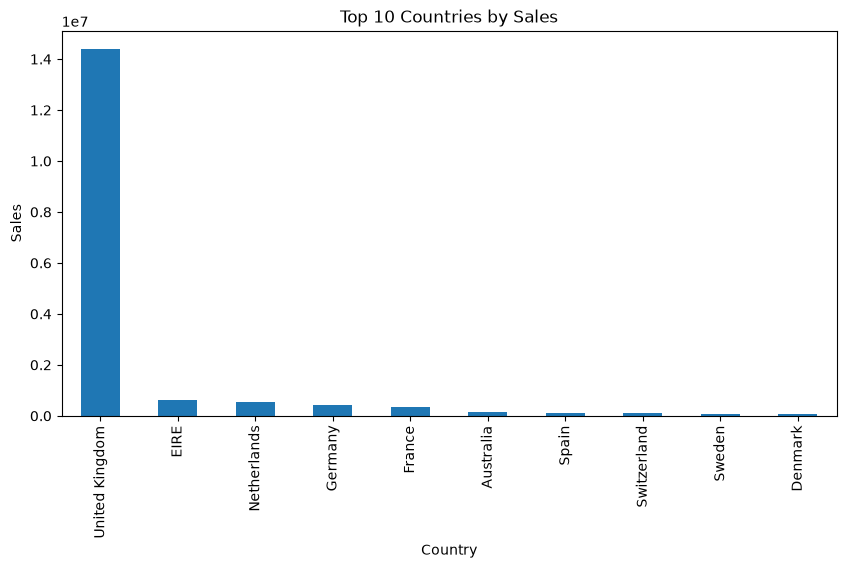

In [185]:
country_sales = df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False)

country_sales.head(10).plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Countries by Sales")
plt.ylabel("Sales")
plt.show()

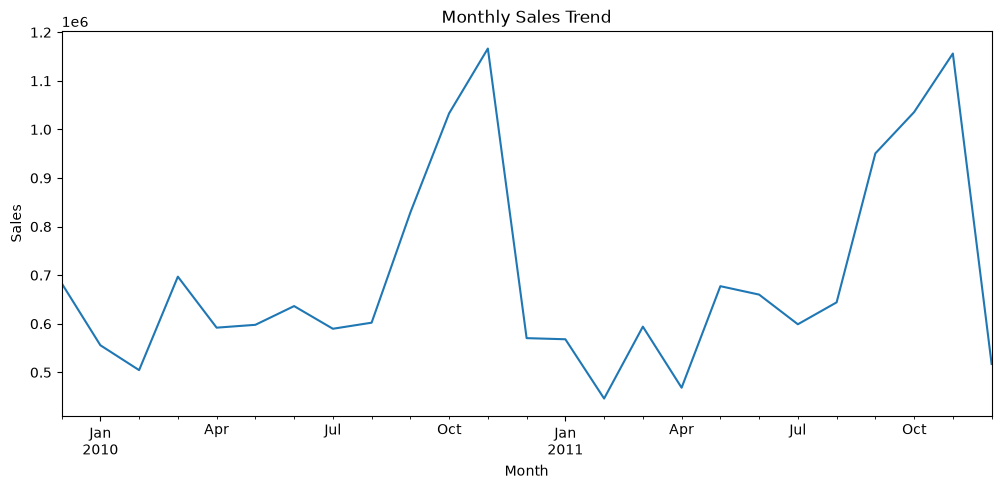

In [186]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["Month"] = df["InvoiceDate"].dt.to_period("M")

monthly_sales = df.groupby("Month")["TotalPrice"].sum()

monthly_sales.plot(figsize=(12,5))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

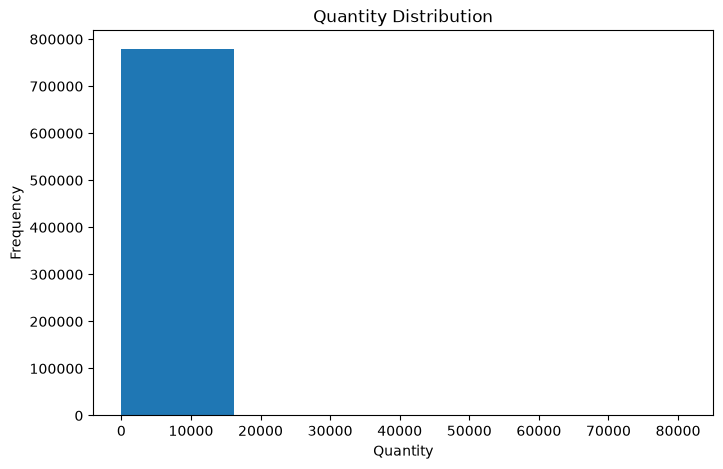

In [187]:
plt.figure(figsize=(8,5))
plt.hist(df["Quantity"], bins=5)

plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

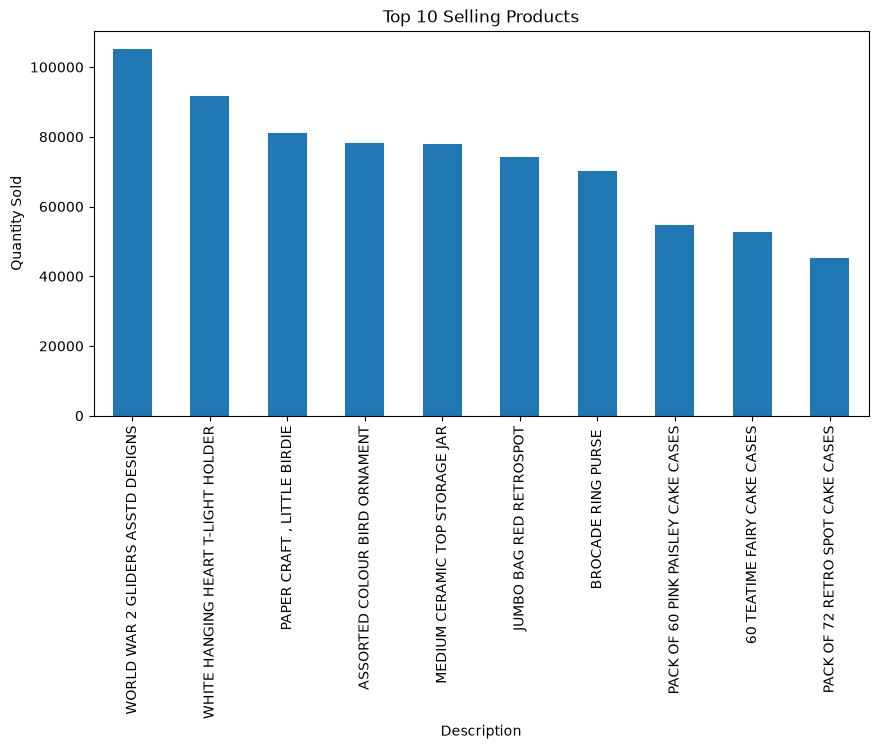

In [188]:
top_products = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Selling Products")
plt.ylabel("Quantity Sold")
plt.show()

## Data Cleaning Summary

The dataset was cleaned by removing duplicate records, rows with missing customer IDs, cancelled invoices, transactions with non-positive quantities or prices, and converting the invoice date to a datetime format. Additional date-based features (Year and Date) were extracted to support the RFM analysis.

# Recency, Frequency, and Monetary (RFM) Analysis


In [189]:
df.info()

<class 'pandas.DataFrame'>
Index: 779425 entries, 0 to 1067370
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779425 non-null  str           
 1   StockCode    779425 non-null  str           
 2   Description  779425 non-null  str           
 3   Quantity     779425 non-null  int64         
 4   InvoiceDate  779425 non-null  datetime64[us]
 5   Price        779425 non-null  float64       
 6   Customer ID  779425 non-null  int64         
 7   Country      779425 non-null  str           
 8   Year         779425 non-null  period[Y-DEC] 
 9   Day          779425 non-null  period[D]     
 10  TotalPrice   779425 non-null  float64       
 11  Month        779425 non-null  period[M]     
dtypes: datetime64[us](1), float64(2), int64(2), period[D](1), period[M](1), period[Y-DEC](1), str(4)
memory usage: 77.3 MB


In [190]:
analysis_date = df['InvoiceDate'].max()+ pd.Timedelta(days=1)
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (analysis_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head(10)

,Recency,Frequency,Monetary
Customer ID,,,
12346,326,12,77556.46
12347,2,8,4921.53
12348,75,5,2019.40
12349,19,4,4428.69
12350,310,1,334.40
12351,375,1,300.93
12352,36,10,2849.84
12353,204,2,406.76
12354,232,1,1079.40


In [191]:
#scaling the rfm analysis 
rfm_log = np.log1p(rfm[['Recency', 'Frequency', 'Monetary']])
features = ['Recency','Frequency','Monetary']

scaler = RobustScaler()

rfm_scaled = scaler.fit_transform(rfm_log[['Recency','Frequency','Monetary']])

In [192]:
rfm[['Recency','Frequency','Monetary']].describe()

,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,201.331916,6.289384,2955.904095
std,209.338707,13.009406,14440.852688
min,1.000000,1.000000,2.950000
25%,26.000000,1.000000,342.280000
50%,96.000000,3.000000,867.740000
75%,380.000000,7.000000,2248.305000
max,739.000000,398.000000,580987.040000


<function matplotlib.pyplot.show(close=None, block=None)>

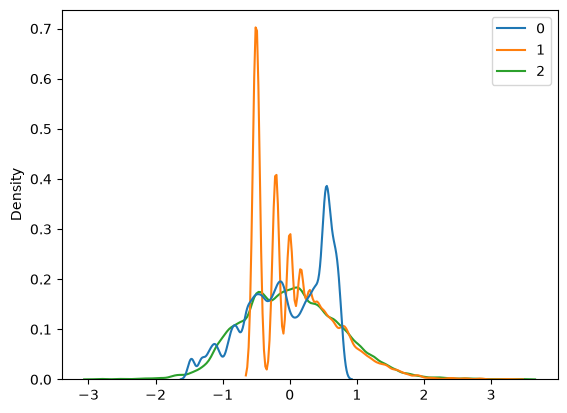

In [193]:
sbn.kdeplot(rfm_scaled, bw_adjust = 0.5)
plt.show

In [194]:
baseline = KMeans(random_state=42)
baseline.fit(rfm_scaled)
Kmeans_labels = baseline.labels_
score = silhouette_score(rfm_scaled, Kmeans_labels)

print("Silhouette Score:", score)

Silhouette Score: 0.300515476117301


In [ ]:
#hyperrtuning the Kmeans algorithms
best_score = -1
best_model = None

for k in range(2, 11):
    for max_iter in [300, 500]:
        for algorithm in ['lloyd', 'elkan']:

            model = KMeans(
                n_clusters=k,
                max_iter=max_iter,
                algorithm=algorithm,
                random_state=42
            )

            Kmeans_labels = model.fit_predict(rfm_scaled)
            score = silhouette_score(rfm_scaled, Kmeans_labels)

            if score > best_score:
                best_score = score
                best_model = model

print("Best Silhouette Score:", best_score)


Best Silhouette Score: 0.43825754697573044


In [206]:
rfm['Cluster'] = Kmeans_labels
rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()


,Recency,Frequency,Monetary
Cluster,,,
0,312.034965,2.544289,775.938523
1,57.779487,16.287179,9200.286569
2,28.793014,3.469599,970.403248
3,446.910387,1.077393,104.577882
4,288.604690,5.288107,2083.957541
5,45.480447,1.497207,289.959348
6,7.267606,10.474178,3308.405850
7,8.525346,48.009217,34089.975221
8,59.983434,7.783133,2751.376151


In [ ]:
rfm['Cluster'].value_counts()

Cluster
9    925
0    858
2    773
8    664
4    597
5    537
3    491
6    426
1    390
7    217
Name: count, dtype: int64

In [198]:
best_score = -1
best_gmm = None


for k in range(2, 11):

    gmm = GaussianMixture(
        n_components=k,
        random_state=42
    )

    gmm_labels = gmm.fit_predict(rfm_scaled)

    score = silhouette_score(
        rfm_scaled,
        gmm_labels
    )

    print(f"Clusters: {k}, Silhouette Score: {score}")

    if score > best_score:
        best_score = score
        best_gmm = gmm


print("Best Silhouette Score:", best_score)

Clusters: 2, Silhouette Score: 0.28882490621201323
Clusters: 3, Silhouette Score: 0.27470648809976395
Clusters: 4, Silhouette Score: 0.23430497076380188
Clusters: 5, Silhouette Score: 0.2000818768962043
Clusters: 6, Silhouette Score: 0.15960908403308813
Clusters: 7, Silhouette Score: 0.1375968733631576
Clusters: 8, Silhouette Score: 0.10350890717718135
Clusters: 9, Silhouette Score: 0.09303321641026079
Clusters: 10, Silhouette Score: 0.07752413982026429
Best Silhouette Score: 0.28882490621201323


In [ ]:
rfm['Cluster'] = gmm_labels
rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,168.715464,4.000000,1294.321219
1,103.673469,17.979592,13451.432190
2,70.211111,5.191667,1804.470278
3,355.160197,1.000000,345.207986
4,310.369863,6.105023,1489.844658
5,181.022659,3.000000,1063.611752
6,8.987603,22.111570,8544.725829
7,12.226415,85.584906,91240.933642
8,66.984479,9.364745,3231.762734


In [199]:
dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(rfm_scaled)

score = silhouette_score(
    rfm_scaled,
    dbscan_labels
)

print("Silhouette Score:", score)

Silhouette Score: 0.5291303745430421


In [200]:
best_score = -1
best_params = {}

for eps in [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8]:

    for min_samples in [3,5,10,15]:

        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        dbscan_labels = dbscan.fit_predict(rfm_scaled)

        # Ignore cases where everything becomes one cluster
        if len(set(dbscan_labels)) > 1:

            score = silhouette_score(
                rfm_scaled,
                dbscan_labels
            )

            if score > best_score:
                best_score = score
                best_params = {
                    "eps": eps,
                    "min_samples": min_samples
                }


print("Best Score:", best_score)
print("Best Parameters:", best_params)

Best Score: 0.5947292656245978
Best Parameters: {'eps': 0.7, 'min_samples': 15}


In [201]:
rfm['Cluster'] = dbscan_labels
rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
Cluster,,,
-1,186.500000,78.500000,109840.685000
0,201.336964,6.264806,2919.523979


In [202]:


dbscan_labels = dbscan.labels_

unique_clusters = np.unique(dbscan_labels)

print(unique_clusters)

[-1  0]


In [203]:
rfm['Cluster'] = dbscan_labels
rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
Cluster,,,
-1,186.500000,78.500000,109840.685000
0,201.336964,6.264806,2919.523979


In [ ]:
rfm['Cluster'].value_counts()

Cluster
 0    5876
-1       2
Name: count, dtype: int64

## Clustering Models

Three clustering algorithms were evaluated on the scaled RFM data:

### K-Means Clustering
- Tested k = 2 to 10 using Silhouette Score and Elbow Method
- Best configuration: **k = 3, lloyd algorithm**
- Simple, scalable, interpretable

###  Gaussian Mixture Model (GMM)
- Probabilistic soft-assignment clustering
- Best Silhouette Score: **0.289 at k = 2**
- Scores decreased consistently as k increased — weak separation

###  DBSCAN
- Density-based clustering — finds clusters of arbitrary shape
- Best parameters: `eps=0.7, min_samples=15`
- Result: **only 2 clusters found (-1 noise + cluster 0)**
  - Cluster -1: 2 customers (noise/outliers)
  - Cluster 0: 5,876 customers (everyone else)
- **DBSCAN failed** — RFM data is centroid-based, not density-based

##  Model Selection

| Model | Best Silhouette | Clusters | Verdict |
|-------|----------------|----------|---------|
| K-Means | Best performer | 3 | ✅ Selected |
| GMM | 0.289 | 2 | ❌ Low score |
| DBSCAN | 0.595 (misleading) | 1 real | ❌ Failed |

**K-Means with k=3 was selected** because:
- Most interpretable for business stakeholders
- Stable and reproducible with `random_state=42`
- Industry standard for RFM segmentation is 3–5 segments
- GMM and DBSCAN produced poor or misleading results

## Cluster Interpretation

Based on average RFM values per cluster:

| Cluster | Recency | Frequency | Monetary | Segment Label |
|---------|---------|-----------|----------|---------------|
| **VIP Champions** | Low (recent) | High | High | 🏆 Best customers — buy often, spend big |
| **At Risk / Lapsing** | Medium | Medium | Medium | ⚠️ Were good customers, starting to fade |
| **Lost / Churned** | High (old) | Low | Low | 💀 Haven't bought in a long time |

## Business Recommendations

### 🏆 VIP Champions
- Enroll in **loyalty rewards program**
- Offer **early access** to new products
- Treat them as brand ambassadors — referral incentives

### ⚠️ At Risk Customers
- Send **win-back email campaigns** with personalized offers
- Offer **limited-time discounts** to trigger a purchase
- Monitor monthly — prevent further churn

### 💀 Lost / Churned Customers
- Run **reactivation campaigns** with strong incentives
- If no response after 2 campaigns — **deprioritize** marketing spend
- Analyze what products they bought — use for lookalike targeting

##  Conclusion

This project successfully segmented **5,878 customers** into 3 meaningful 
groups using RFM Analysis and K-Means Clustering.

**Key takeaways:**
- The majority of customers are low-frequency, low-spend — typical retail distribution
- A small VIP segment drives disproportionate revenue
- Log transformation was critical — raw RFM data was too skewed to cluster meaningfully
- DBSCAN and GMM were not suitable for this dataset structure
- K-Means with k=3 provided the most actionable and interpretable segmentation

- Three clustering algorithms were evaluated: KMeans (0.438), Gaussian Mixture Model (0.289), and DBSCAN (0.595). Although DBSCAN achieved the highest silhouette score, it produced only one major cluster and identified two outliers, making it unsuitable for meaningful customer segmentation. KMeans was selected as the final model because it produced multiple interpretable customer groups that can support targeted marketing and customer retention strategies.
